In [ ]:
# ===============================================
# Cell 0 : prepare data folders & 512-px tiles
#           (⭑ UPDATED – 80/20 split for Potsdam)
# ===============================================

import os, glob, cv2, shutil, itertools
from tqdm import tqdm

# -- 0.1  folder names --------------------------------------------------------
POTSDAM_TOP    = "/content/top_Potsdam"
POTSDAM_LABELS = "/content/Potsdam_ground_truth"
VAIH_TOP       = "/content/top_Vaihingen"
VAIH_LABELS    = "/content/Vaihingen_ground_truth"

# -- 0.2  tiling helper -------------------------------------------------------
def tile(src_path, dst_dir, size=512, is_mask=False):
    os.makedirs(dst_dir, exist_ok=True)
    img  = cv2.imread(src_path, cv2.IMREAD_UNCHANGED)
    h, w = img.shape[:2]
    name = os.path.splitext(os.path.basename(src_path))[0]
    for y in range(0, h, size):
        for x in range(0, w, size):
            crop = img[y:y+size, x:x+size]
            if crop.shape[0] != size or crop.shape[1] != size: continue
            fn = f"{name}_{y//size}_{x//size}.png"
            cv2.imwrite(os.path.join(dst_dir, fn),
                        crop[:, :, :3] if not is_mask else crop,
                        [cv2.IMWRITE_PNG_COMPRESSION, 0])

# -- 0.3  Potsdam → 80% train • 20% val ---------------------------------------
potsdam_imgs   = sorted(glob.glob(POTSDAM_TOP    + "/*.tif"))
potsdam_masks  = sorted(glob.glob(POTSDAM_LABELS + "/*.tif"))
cut            = int(len(potsdam_imgs) * 0.8)

split_cfg = [
    ("potsdam_train_seg_data", potsdam_imgs[:cut],  potsdam_masks[:cut],  "train"),
    ("potsdam_val_seg_data",   potsdam_imgs[cut:],  potsdam_masks[cut:],  "val")
]

for name, imgs, msks, tag in split_cfg:
    for d in ["images", "masks"]:
        os.makedirs(f"./seg_datasets/{name}/{d}", exist_ok=True)
    for p in tqdm(imgs, desc=f"Potsdam {tag} RGB"):
        tile(p, f"./seg_datasets/{name}/images", is_mask=False)
    for p in tqdm(msks, desc=f"Potsdam {tag} mask"):
        tile(p, f"./seg_datasets/{name}/masks",  is_mask=True)

# -- 0.4  CycleGAN folders (Potsdam2Vaihingen) --------------------------------
for split, pct in [("train", 0.85), ("test", 0.15)]:
    for dom, top_dir in [("A", POTSDAM_TOP), ("B", VAIH_TOP)]:
        out = f"./datasets/potsdam2vaihingen/{split}{dom}"
        os.makedirs(out, exist_ok=True)
        files = sorted(glob.glob(top_dir + "/*.tif"))
        cut   = int(len(files) * pct)
        pick  = files[:cut] if split == "train" else files[cut:]
        for p in tqdm(pick, desc=f"{split}{dom}"):
            tile(p, out, is_mask=False)

# -- 0.5  Vaihingen test set --------------------------------------------------
for d in ["images", "masks"]:
    os.makedirs(f"./seg_datasets/vaihingen_test_seg_data/{d}", exist_ok=True)

for p in tqdm(sorted(glob.glob(VAIH_TOP + "/*.tif"))[-6:],  desc="Vaih test img"):
    tile(p, "./seg_datasets/vaihingen_test_seg_data/images", is_mask=False)
for p in tqdm(sorted(glob.glob(VAIH_LABELS + "/*.tif"))[-6:], desc="Vaih test msk"):
    tile(p, "./seg_datasets/vaihingen_test_seg_data/masks", is_mask=True)

print("✅ All data folders are ready (80/20 Potsdam split).")


Vaih test msk: 100%|██████████| 6/6 [00:00<00:00,  6.83it/s]

✅ All data folders are ready (80/20 Potsdam split).


In [ ]:
# ---------- color2index for segmentation masks ------------
palette_rgb = {            # (R,G,B) : class-id
    (255,255,255): 0,      # impervious
    (0,0,255): 1,          # building
    (0,255,255): 2,        # low vegetation
    (0,255,0): 3,          # trees
    (255,255,0): 4,        # cars
    (255,0,0): 5           # clutter
}

def color2index(mask_bgr):
    h, w, _ = mask_bgr.shape
    out = np.zeros((h, w), np.uint8)
    for (r, g, b), idx in palette_rgb.items():
        bgr = (b, g, r)
        m = (mask_bgr[..., 0] == bgr[0]) & (mask_bgr[..., 1] == bgr[1]) & (mask_bgr[..., 2] == bgr[2])
        out[m] = idx
    return out

# ---------- MeanIoU_Custom Metric ------------
class MeanIoU_Custom(tf.keras.metrics.Metric):
    def __init__(self, ncls=6, name="mean_iou", **kw):
        super().__init__(name=name, **kw)
        self.ncls = ncls
        self.cm = self.add_weight(name="cm", shape=(ncls, ncls), initializer="zeros", dtype=tf.float32)
    def update_state(self, y_true, y_pred, **kw):
        yt = tf.argmax(y_true, -1)
        yp = tf.argmax(y_pred, -1)
        cm = tf.math.confusion_matrix(tf.reshape(yt, [-1]),
                                      tf.reshape(yp, [-1]),
                                      num_classes=self.ncls,
                                      dtype=tf.float32)
        self.cm.assign_add(cm)
    def result(self):
        sr = tf.reduce_sum(self.cm, 1)
        sc = tf.reduce_sum(self.cm, 0)
        d = tf.linalg.diag_part(self.cm)
        iou = tf.where(sr + sc - d > 0, d / (sr + sc - d), tf.zeros_like(d))
        return tf.reduce_mean(iou)
    def reset_states(self):
        self.cm.assign(tf.zeros_like(self.cm))

# ---------- build_deeplabv3 Model (basic version) ------------
def _aspp(x, f, d):
    x = layers.Conv2D(f, 3, padding="same", dilation_rate=d, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_deeplabv3(num_classes=6, shape=(256, 256, 3)):
    base = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=shape)
    feat = base.get_layer("conv4_block6_out").output  # 1/16 scale feature map

    b0 = layers.Conv2D(256, 1, use_bias=False)(feat)
    b0 = layers.BatchNormalization()(b0)
    b0 = layers.ReLU()(b0)

    b1, b2, b3 = (_aspp(feat, 256, d) for d in (6, 12, 18))

    pool = layers.GlobalAveragePooling2D()(feat)
    pool = layers.Reshape((1, 1, -1))(pool)
    pool = layers.Conv2D(256, 1, use_bias=False)(pool)
    pool = layers.BatchNormalization()(pool)
    pool = layers.ReLU()(pool)
    pool = layers.UpSampling2D(size=(shape[0] // 16, shape[1] // 16), interpolation="bilinear")(pool)

    x = layers.Concatenate()([b0, b1, b2, b3, pool])
    x = layers.Conv2D(256, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.UpSampling2D(size=4, interpolation="bilinear")(x)
    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.UpSampling2D(size=4, interpolation="bilinear")(x)
    out = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    return Model(base.input, out)

# ---------- SegDataLoader for segmentation ------------
class SegDataLoader:
    def __init__(self, name="potsdam_train_seg_data", res=(256,256), ncls=6):
        imdir = f"./seg_datasets/{name}/images"
        mskdir = f"./seg_datasets/{name}/masks"
        img_files = sorted(glob.glob(os.path.join(imdir, "*.png")))
        self.pairs = []
        for imp in img_files:
            fn = os.path.basename(imp)
            if "_RGB" in fn:
                mfn = fn.replace("_RGB", "_label")
            elif "_IRRG" in fn:
                mfn = fn.replace("_IRRG", "_label")
            else:
                mfn = fn
            msp = os.path.join(mskdir, mfn)
            if os.path.exists(msp):
                self.pairs.append((imp, msp))
        self.size = len(self.pairs)
        self.res = res
        self.ncls = ncls
        print(f"✓ loader: {self.size} image–mask pairs ready.")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        imp, msp = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(imp), cv2.COLOR_BGR2RGB)
        msk = cv2.imread(msp, cv2.IMREAD_COLOR)
        img = cv2.resize(img, self.res)
        msk = cv2.resize(msk, self.res, interpolation=cv2.INTER_NEAREST)
        cmap = color2index(msk)
        oh = tf.keras.utils.to_categorical(cmap, self.ncls)
        return img.astype(np.float32) / 255.0, oh

    def batch(self, bs=4, shuffle=True):
        idxs = np.arange(self.size)
        while True:
            if shuffle:
                np.random.shuffle(idxs)
            for st in range(0, self.size, bs):
                xs, ys = [], []
                for i in idxs[st : st + bs]:
                    x, y = self[i]
                    xs.append(x)
                    ys.append(y)
                yield np.array(xs), np.array(ys)


✓ loader: 3630 image–mask pairs ready.
✓ loader: 968 image–mask pairs ready.

--- Epoch 1/100 ---
907/907 ━━━━━━━━━━━━━━━━━━━━ 121s 78ms/step - accuracy: 0.6687 - loss: 0.9509 - mean_iou: 0.3676 - val_accuracy: 0.1086 - val_loss: 6.6453 - val_mean_iou: 0.0386
⭐ Best model updated at epoch 1 (val_mean_iou=0.0386)

--- Epoch 2/100 ---
907/907 ━━━━━━━━━━━━━━━━━━━━ 67s 74ms/step - accuracy: 0.7957 - loss: 0.5681 - mean_iou: 0.5260 - val_accuracy: 0.7773 - val_loss: 0.6818 - val_mean_iou: 0.5717
⭐ Best model updated at epoch 2 (val_mean_iou=0.5717)

--- Epoch 3/100 ---
907/907 ━━━━━━━━━━━━━━━━━━━━ 69s 76ms/step - accuracy: 0.8304 - loss: 0.4630 - mean_iou: 0.5860 - val_accuracy: 0.7209 - val_loss: 1.1991 - val_mean_iou: 0.5314

--- Epoch 4/100 ---
907/907 ━━━━━━━━━━━━━━━━━━━━ 67s 73ms/step - accuracy: 0.8493 - loss: 0.4089 - mean_iou: 0.6193 - val_accuracy: 0.7464 - val_loss: 0.7707 - val_mean_iou: 0.5650

--- Epoch 5/100 ---
907/907 ━━━━━━━━━━━━━━━━━━━━ 67s 74ms/step - accuracy: 0.8673 - l

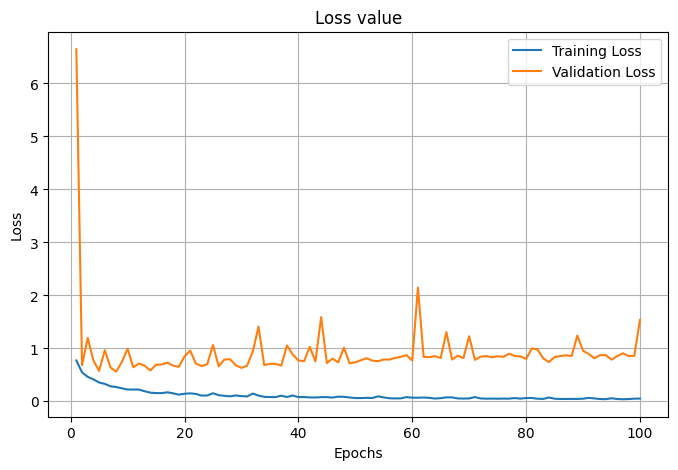

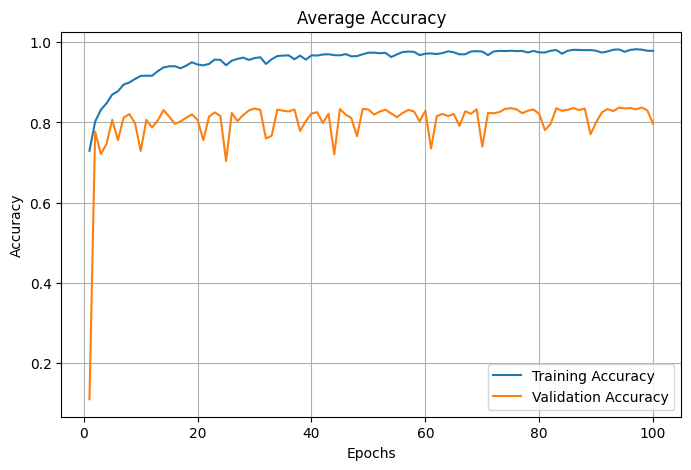

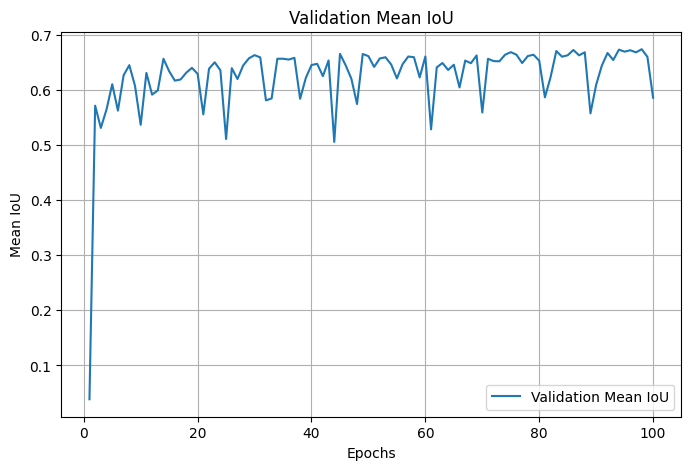


✅ Best model from epoch 98 reloaded!

──────── Final Validation Set Evaluation ────────
test overall accuracy : 0.8373
test overall mIoU     : 0.6795

per-class results
───────────────────────────────────────────────
impervious    acc = 0.8777   iou = 0.7738
building      acc = 0.8767   iou = 0.8405
low veg       acc = 0.7891   iou = 0.5898
trees         acc = 0.7856   iou = 0.6174
cars          acc = 0.8251   iou = 0.7294
clutter       acc = 0.6474   iou = 0.5263


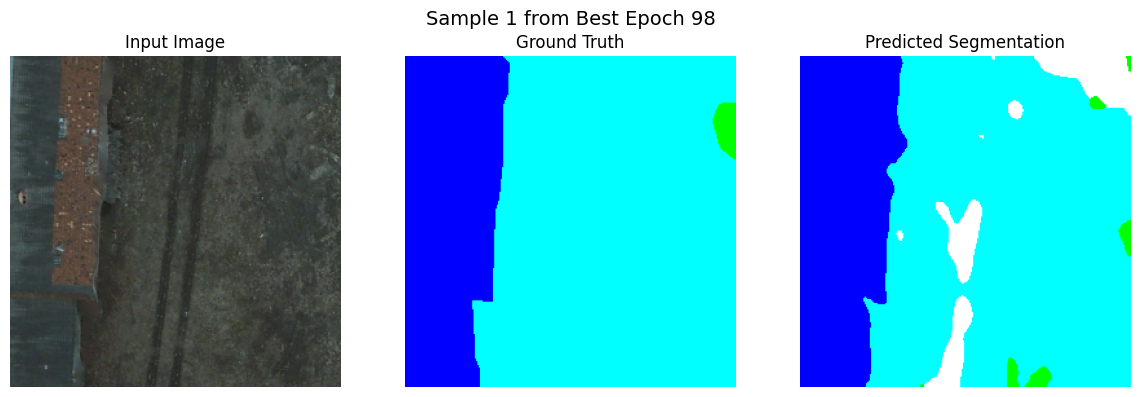

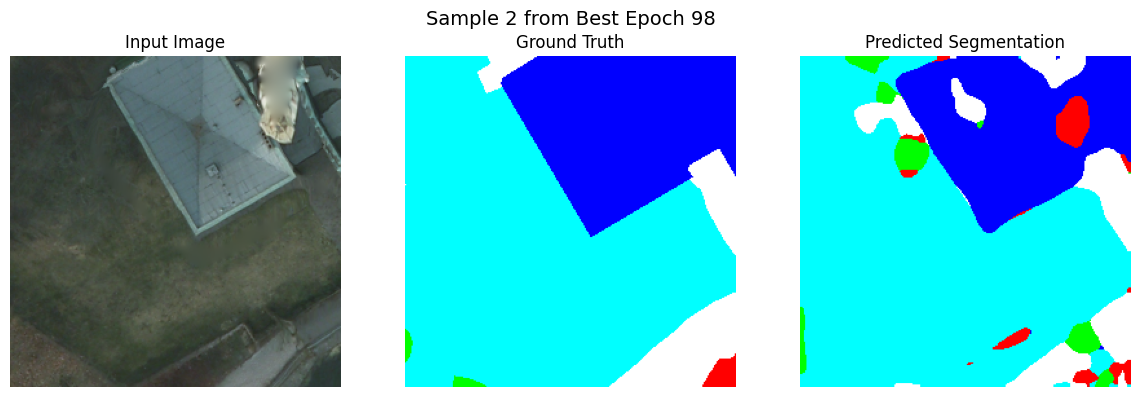

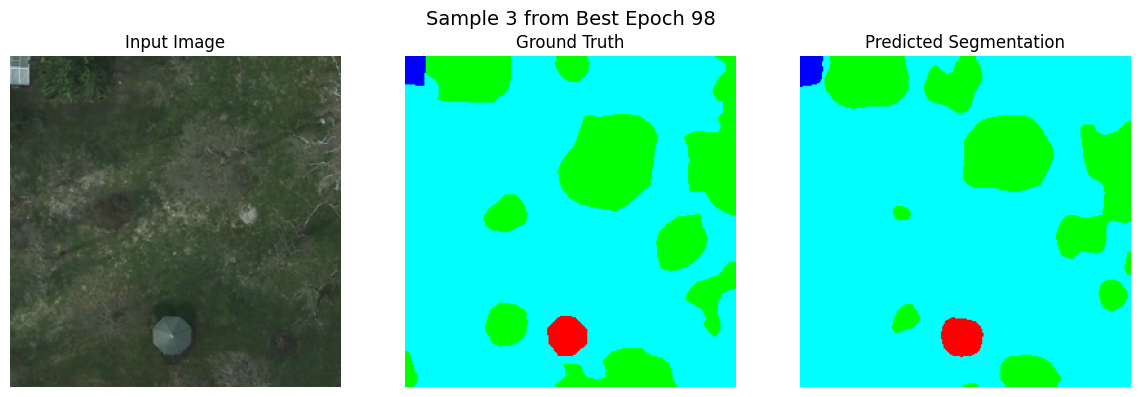

In [ ]:
# ===============================================
# Cell 1 : Step 1 – segmentation (source-domain)
#           (⭑ UPDATED – fully automated best save & eval + prediction visualizer)
# ===============================================

import tensorflow as tf, numpy as np, glob, os, cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

# (palette, color2index, MeanIoU_Custom, build_deeplabv3, SegDataLoader assumed already defined)

# ---------- 1.5  train WITH 80/20 Potsdam SPLIT ------------------

train_loader = SegDataLoader("potsdam_train_seg_data")
val_loader   = SegDataLoader("potsdam_val_seg_data")

model = build_deeplabv3(6, (256, 256, 3))
model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", MeanIoU_Custom(6)]
)

# manually track best validation mIoU
best_val_miou = -np.inf
best_epoch = -1

# manually collect history
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": [], "val_mean_iou": []}

# full 100 epochs training
for epoch in range(100):
    print(f"\n--- Epoch {epoch+1}/100 ---")

    h = model.fit(
        train_loader.batch(bs=4),
        steps_per_epoch=max(1, train_loader.size // 4),
        epochs=1,
        validation_data=val_loader.batch(bs=4, shuffle=False),
        validation_steps=max(1, val_loader.size // 4),
        verbose=1
    )

    # update history
    for k in history.keys():
        if k in h.history:
            history[k].append(h.history[k][0])

    val_miou = h.history["val_mean_iou"][0]

    # save best model manually
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch + 1
        model.save_weights("seg_potsdam_best.weights.h5")
        print(f"⭐ Best model updated at epoch {best_epoch} (val_mean_iou={best_val_miou:.4f})")

print(f"\n✅ Training complete! Best epoch = {best_epoch} (val_mean_iou={best_val_miou:.4f})")

# ===============================================
# 📈 PLOTTING SECTION
# ===============================================

# plot training loss
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history["loss"])+1), history["loss"], label='Training Loss')
plt.plot(range(1, len(history["val_loss"])+1), history["val_loss"], label='Validation Loss')
plt.title('Loss value')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history["accuracy"])+1), history["accuracy"], label='Training Accuracy')
plt.plot(range(1, len(history["val_accuracy"])+1), history["val_accuracy"], label='Validation Accuracy')
plt.title('Average Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# plot validation mean IoU
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history["val_mean_iou"])+1), history["val_mean_iou"], label='Validation Mean IoU')
plt.title('Validation Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('Mean IoU')
plt.grid(True)
plt.legend()
plt.show()

# ===============================================
# ✅ AUTOMATIC BEST MODEL RELOAD AND EVALUATION
# ===============================================

# reload the best saved weights
model.load_weights("seg_potsdam_best.weights.h5")
print(f"\n✅ Best model from epoch {best_epoch} reloaded!")

# quick evaluation on validation set
yt, yp = [], []
for i in range(len(val_loader)):
    x, y_true = val_loader[i]
    y_pred = model.predict(x[None], verbose=0)[0]
    yt.append(np.argmax(y_true, -1).flatten())
    yp.append(np.argmax(y_pred, -1).flatten())

yt = np.concatenate(yt)
yp = np.concatenate(yp)
cm = confusion_matrix(yt, yp, labels=range(6))

overall_acc = cm.diagonal().sum() / cm.sum()

# per-class accuracy and IoU
class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)

ious = []
for c in range(6):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    denom = tp + fp + fn
    ious.append(tp / denom if denom > 0 else 0.0)

overall_miou = np.mean(ious)

# Final pretty print
cls_names = ["impervious", "building", "low veg", "trees", "cars", "clutter"]

print("\n──────── Final Validation Set Evaluation ────────")
print(f"test overall accuracy : {overall_acc:.4f}")
print(f"test overall mIoU     : {overall_miou:.4f}\n")
print("per-class results")
print("───────────────────────────────────────────────")
for name, acc, iou in zip(cls_names, class_acc, ious):
    print(f"{name:<12s}  acc = {acc:.4f}   iou = {iou:.4f}")

# ===============================================
# ✅ VISUALIZE BEST EPOCH PREDICTIONS
# ===============================================

def index2color(index_map):
    color_map = {
        0: (255, 255, 255),  # impervious
        1: (0, 0, 255),      # building
        2: (0, 255, 255),    # low vegetation
        3: (0, 255, 0),      # trees
        4: (255, 255, 0),    # cars
        5: (255, 0, 0)       # clutter
    }
    h, w = index_map.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in color_map.items():
        color_image[index_map == cls] = color
    return color_image

# randomly pick N samples from validation set to visualize
N = 3
indices = np.random.choice(len(val_loader), size=N, replace=False)

for i, idx in enumerate(indices):
    x, y_true = val_loader[idx]
    y_pred = model.predict(x[None], verbose=0)[0]

    y_true_idx = np.argmax(y_true, axis=-1)
    y_pred_idx = np.argmax(y_pred, axis=-1)

    img_disp  = (x * 255).astype(np.uint8)
    gt_disp   = index2color(y_true_idx)
    pred_disp = index2color(y_pred_idx)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Sample {i+1} from Best Epoch {best_epoch}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(img_disp)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_disp)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Segmentation")
    plt.imshow(pred_disp)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


✓ loader: 88 image–mask pairs ready.

──────── segmentation evaluation (Vaihingen test) ────────
test loss        : 4.8704
overall accuracy : 0.3692
overall mIoU     : 0.1596

per-class results
───────────────────────────────────────────────
impervious    acc = 0.3691   iou = 0.3055
building      acc = 0.6453   iou = 0.4331
low veg       acc = 0.0786   iou = 0.0544
trees         acc = 0.1457   iou = 0.1336
cars          acc = 0.0384   iou = 0.0308
clutter       acc = 0.0000   iou = 0.0000

📸 Showing top 3 best predictions (by IoU)...


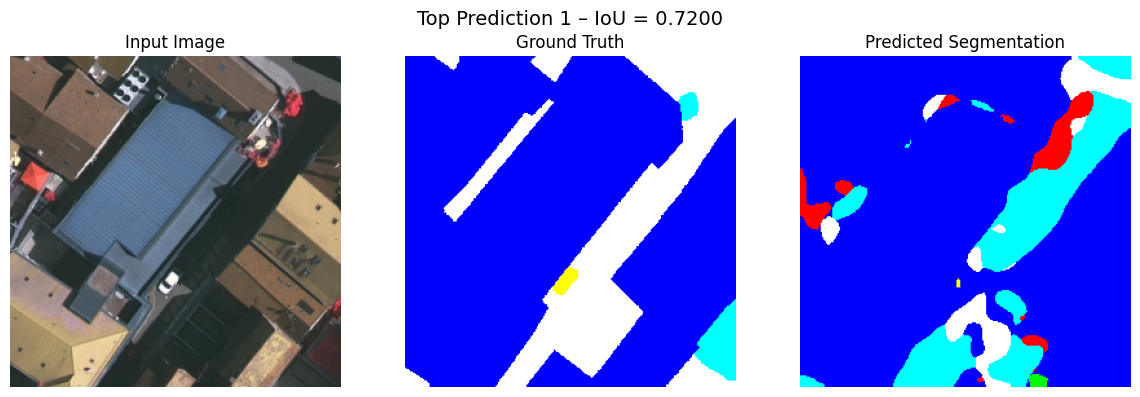

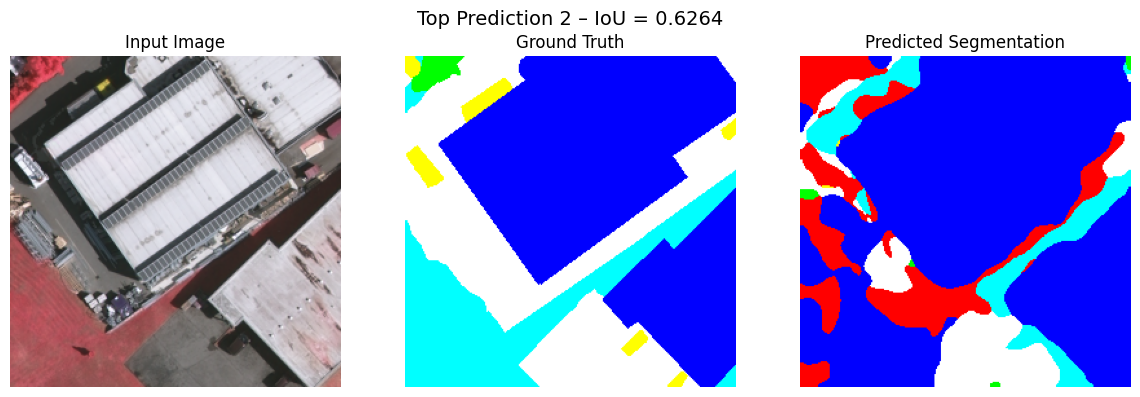

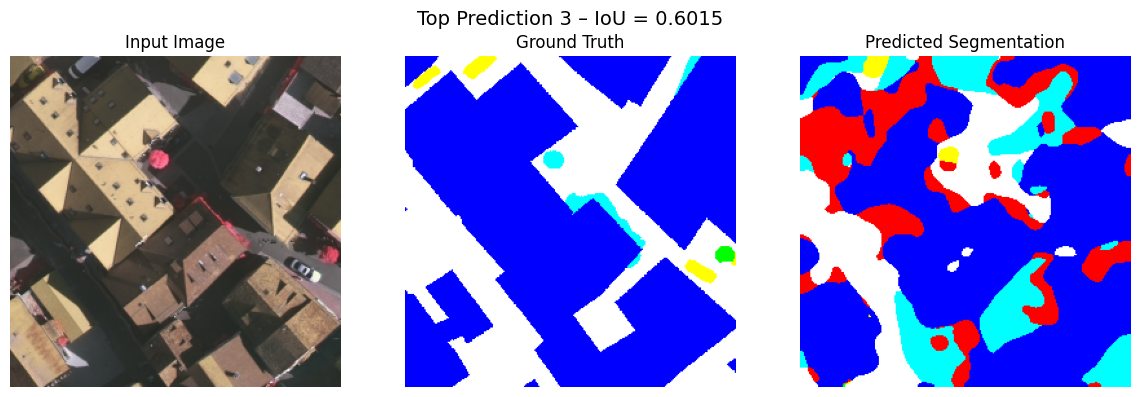

In [20]:
# ===============================================
# Cell 1.1 : Evaluate trained DeeplabV3
# ===============================================

import numpy as np, tensorflow as tf, glob, cv2, os
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

# -------- 2.1 rebuild network & load weights ------------------
model = build_deeplabv3(num_classes=6, shape=(256,256,3))
model.load_weights("seg_potsdam_best.weights.h5")
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy", MeanIoU_Custom(6)])

# -------- 2.2 prepare Vaihingen test loader -------------------
test_loader = SegDataLoader("vaihingen_test_seg_data", res=(256,256), ncls=6)

# -------- 2.3 quick Keras evaluate (loss & overall acc) -------
test_loss, test_acc, _ = model.evaluate(test_loader.batch(bs=4, shuffle=False), steps=max(1, test_loader.size // 4), verbose=0)

# -------- 2.4 confusion matrix -------------------------------
yt, yp = [], []
for i in range(len(test_loader)):
    x, y_true = test_loader[i]
    y_pred    = model.predict(x[None], verbose=0)[0]
    yt.append(np.argmax(y_true, -1).flatten())
    yp.append(np.argmax(y_pred, -1).flatten())
yt = np.concatenate(yt)
yp = np.concatenate(yp)
cm = confusion_matrix(yt, yp, labels=range(6))
overall_acc = cm.diagonal().sum() / cm.sum()

# per-class acc & IoU
class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
ious = []
for c in range(6):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    denom = tp + fp + fn
    ious.append(tp / denom if denom > 0 else 0.0)
overall_miou = np.mean(ious)

# -------- 2.5 pretty print ------------------------------------
cls_names = ["impervious", "building", "low veg", "trees", "cars", "clutter"]
print("\n──────── segmentation evaluation (Vaihingen test) ────────")
print(f"test loss        : {test_loss:.4f}")
print(f"overall accuracy : {overall_acc:.4f}")
print(f"overall mIoU     : {overall_miou:.4f}\n")
print("per-class results")
print("───────────────────────────────────────────────")
for name, acc, iou in zip(cls_names, class_acc, ious):
    print(f"{name:<12s}  acc = {acc:.4f}   iou = {iou:.4f}")

# -------- 2.6 visualize predictions for ALL test images -------
def index2color(index_map):
    color_map = {
        0: (255, 255, 255),  # impervious
        1: (0, 0, 255),      # building
        2: (0, 255, 255),    # low vegetation
        3: (0, 255, 0),      # trees
        4: (255, 255, 0),    # cars
        5: (255, 0, 0)       # clutter
    }
    h, w = index_map.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in color_map.items():
        color_image[index_map == cls] = color
    return color_image

# -------- 2.6 visualize top 3 best predictions ------------------------

def index2color(index_map):
    color_map = {
        0: (255, 255, 255),  # impervious
        1: (0, 0, 255),      # building
        2: (0, 255, 255),    # low vegetation
        3: (0, 255, 0),      # trees
        4: (255, 255, 0),    # cars
        5: (255, 0, 0)       # clutter
    }
    h, w = index_map.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in color_map.items():
        color_image[index_map == cls] = color
    return color_image

# store IoUs and predictions for all samples
sample_results = []

for i in range(len(test_loader)):
    x, y_true = test_loader[i]
    y_pred = model.predict(x[None], verbose=0)[0]

    y_true_idx = np.argmax(y_true, axis=-1)
    y_pred_idx = np.argmax(y_pred, axis=-1)

    intersection = np.sum((y_true_idx == y_pred_idx) & (y_true_idx != 255))
    union = np.sum((y_true_idx != 255) | (y_pred_idx != 255))
    sample_iou = intersection / union if union > 0 else 0.0

    sample_results.append((sample_iou, x, y_true_idx, y_pred_idx))

# sort by IoU descending and take top 3
top_samples = sorted(sample_results, key=lambda x: x[0], reverse=True)[:3]

print("\n📸 Showing top 3 best predictions (by IoU)...")
for i, (iou, x, y_true_idx, y_pred_idx) in enumerate(top_samples):
    img_disp  = (x * 255).astype(np.uint8)
    gt_disp   = index2color(y_true_idx)
    pred_disp = index2color(y_pred_idx)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Top Prediction {i+1} – IoU = {iou:.4f}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(img_disp)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_disp)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Segmentation")
    plt.imshow(pred_disp)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


[Ep   0]  D_acc 86.76%  G_loss 6.238
[Ep   1]  D_acc 86.75%  G_loss 5.813
[Ep   2]  D_acc 86.77%  G_loss 5.574
[Ep   3]  D_acc 86.77%  G_loss 5.424
[Ep   4]  D_acc 86.77%  G_loss 5.293
[Ep   5]  D_acc 86.82%  G_loss 5.217
[Ep   6]  D_acc 86.96%  G_loss 5.115
[Ep   7]  D_acc 87.32%  G_loss 5.015
[Ep   8]  D_acc 87.90%  G_loss 4.935
[Ep   9]  D_acc 88.65%  G_loss 4.854
[Ep  10]  D_acc 89.52%  G_loss 4.780
[Ep  11]  D_acc 90.40%  G_loss 4.712
[Ep  12]  D_acc 91.29%  G_loss 4.650
[Ep  13]  D_acc 92.14%  G_loss 4.593
[Ep  14]  D_acc 92.90%  G_loss 4.541
[Ep  15]  D_acc 93.64%  G_loss 4.491
[Ep  16]  D_acc 94.35%  G_loss 4.434
[Ep  17]  D_acc 95.05%  G_loss 4.388
[Ep  18]  D_acc 95.77%  G_loss 4.337
[Ep  19]  D_acc 96.42%  G_loss 4.293
[Ep  20]  D_acc 97.06%  G_loss 4.256
[Ep  21]  D_acc 97.58%  G_loss 4.227
[Ep  22]  D_acc 98.17%  G_loss 4.187
[Ep  23]  D_acc 98.74%  G_loss 4.149
[Ep  24]  D_acc 99.26%  G_loss 4.114
[Ep  25]  D_acc 99.78%  G_loss 4.080
[Ep  26]  D_acc 100.29%  G_loss 4.048


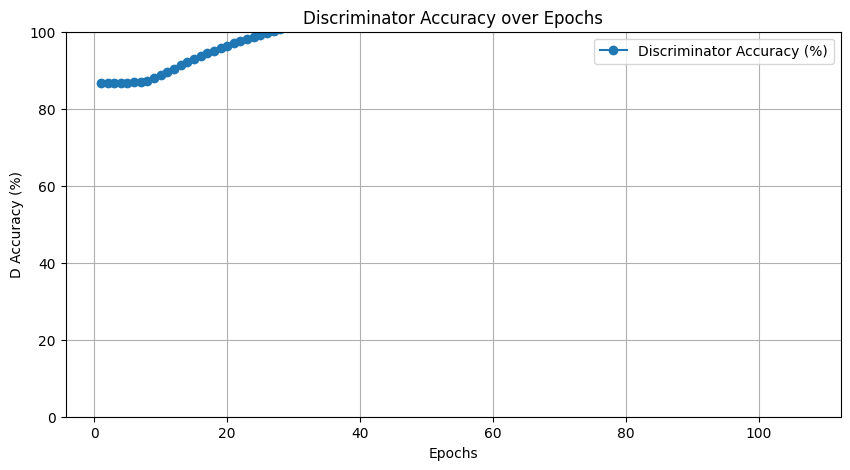

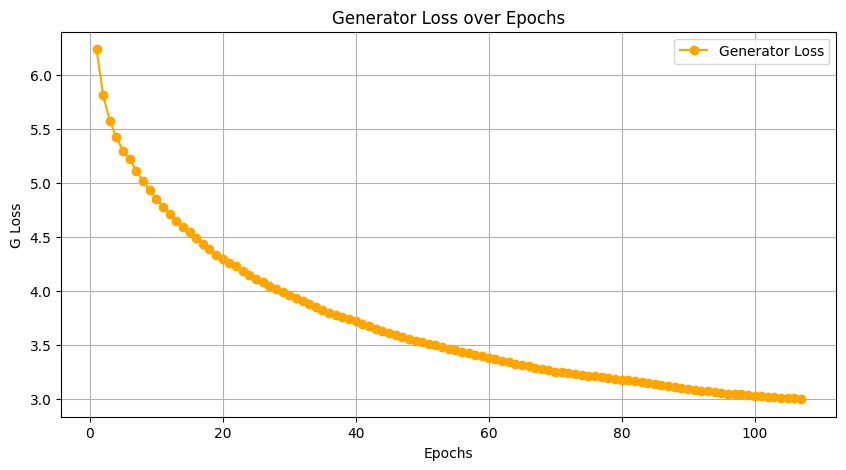

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


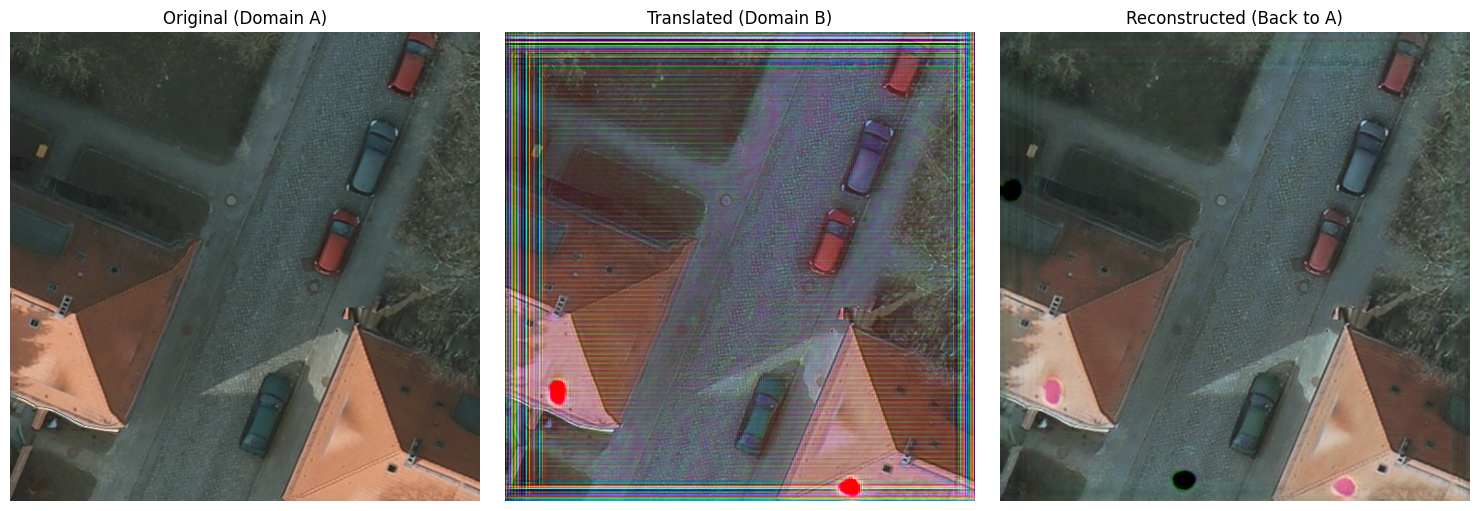

✅ Step 2 complete – CycleGAN fully trained, plotted, and visualized!


In [ ]:
# ===============================================
# Cell 2 : CycleGAN (Potsdam → Vaihingen) – Clean Final Version
# ===============================================

import tensorflow as tf, numpy as np, glob, cv2, os, pathlib
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import Conv2D, UpSampling2D, LeakyReLU
from tensorflow.keras.optimizers import Adam

# ---------- Helper Layers ----------------------------------------------------
class InstanceNorm(layers.Layer):
    def __init__(self, eps=1e-5): super().__init__(); self.eps = eps
    def call(self, x):
        m, v = tf.nn.moments(x, [1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.eps)

class ReflectPad(layers.Layer):
    def __init__(self, pad=(1,1)): super().__init__(); self.pad = pad
    def call(self, x):
        pw, ph = self.pad
        return tf.pad(x, [[0,0],[ph,ph],[pw,pw],[0,0]], mode="REFLECT")

# ---------- Data Loader ------------------------------------------------------
class DataLoader:
    def __init__(self, ds="potsdam2vaihingen", res=(512,512)):
        self.ds, self.res = ds, res
    @staticmethod
    def _read(p): return cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    def load_batch(self, bs=1):
        A = glob.glob(f"./datasets/{self.ds}/trainA/*.png")
        B = glob.glob(f"./datasets/{self.ds}/trainB/*.png")
        n = min(len(A), len(B)) // bs
        A = np.random.choice(A, n*bs, replace=False)
        B = np.random.choice(B, n*bs, replace=False)
        for i in range(n):
            a, b = self._read(A[i]), self._read(B[i])
            a, b = cv2.resize(a, self.res), cv2.resize(b, self.res)
            if np.random.rand() > .5: a, b = np.fliplr(a), np.fliplr(b)
            a = a.astype(np.float32)/127.5 - 1.; b = b.astype(np.float32)/127.5 - 1.
            yield a[None], b[None]

# ---------- CycleGAN Model ---------------------------------------------------
class CycleGAN:
    def __init__(self, dataset="potsdam2vaihingen", img_size=512):
        self.img_shape  = (img_size, img_size, 3)
        self.lambda_cyc = 10.0
        self.lambda_id  = 5.0
        self.data_loader = DataLoader(dataset, (img_size, img_size))

        patch = img_size // 16
        self.disc_patch = (patch, patch, 1)
        opt = Adam(2e-4, 0.5)

        # Discriminators
        self.d_A = self._build_discriminator()
        self.d_B = self._build_discriminator()
        for d in (self.d_A, self.d_B):
            d.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

        # Generators
        self.g_AB = self._build_generator()
        self.g_BA = self._build_generator()

        # Combined model
        img_A = Input(self.img_shape)
        img_B = Input(self.img_shape)
        fake_B = self.g_AB(img_A)
        fake_A = self.g_BA(img_B)
        recon_A = self.g_BA(fake_B)
        recon_B = self.g_AB(fake_A)
        idt_A   = self.g_BA(img_A)
        idt_B   = self.g_AB(img_B)

        self.d_A.trainable = self.d_B.trainable = False
        valid_A = self.d_A(fake_A)
        valid_B = self.d_B(fake_B)

        self.combined = Model([img_A, img_B],
                              [valid_A, valid_B,
                               recon_A, recon_B,
                               idt_A,   idt_B])
        self.combined.compile(
            loss=["binary_crossentropy","binary_crossentropy",
                  "mae","mae","mae","mae"],
            loss_weights=[1,1,self.lambda_cyc,self.lambda_cyc,self.lambda_id,self.lambda_id],
            optimizer=opt)

    def _build_generator(self, base=64):
        f = base
        ip = x = Input(self.img_shape)
        x = ReflectPad((3,3))(x)
        x = Conv2D(f,7,padding="valid",use_bias=False)(x)
        x = InstanceNorm()(x); x = LeakyReLU(0.2)(x)

        skips = []
        for i in range(4):
            f *= 2 if i else 2
            x = Conv2D(f,4,strides=2,padding="same",use_bias=False)(x)
            x = InstanceNorm()(x); x = LeakyReLU(0.2)(x)
            if i < 3: skips.append(x)

        def res(z,ch):
            y = ReflectPad((1,1))(z)
            y = Conv2D(ch,3,padding="valid",use_bias=False)(y)
            y = InstanceNorm()(y); y = LeakyReLU(0.2)(y)
            y = ReflectPad((1,1))(y)
            y = Conv2D(ch,3,padding="valid",use_bias=False)(y)
            y = InstanceNorm()(y)
            return layers.Add()([z,y])
        for _ in range(9): x = res(x, f)

        for skip in reversed(skips):
            x = UpSampling2D()(x); f //= 2
            x = Conv2D(f,4,padding="same",use_bias=False)(x)
            x = InstanceNorm()(x); x = LeakyReLU(0.2)(x)
            x = layers.Concatenate()([x, skip])

        f //= 2
        x = UpSampling2D()(x)
        x = Conv2D(f,4,padding="same",use_bias=False)(x)
        x = InstanceNorm()(x); x = LeakyReLU(0.2)(x)

        x = ReflectPad((3,3))(x)
        out = Conv2D(3,7,padding="valid",activation="tanh")(x)
        return Model(ip, out)

    def _build_discriminator(self, df=64):
        def dlayer(z,f,norm=True):
            z = Conv2D(f,4,strides=2,padding="same")(z)
            z = LeakyReLU(0.2)(z)
            return InstanceNorm()(z) if norm else z
        ip = x = Input(self.img_shape)
        x = dlayer(x,df,False); x = dlayer(x,df*2); x = dlayer(x,df*4); x = dlayer(x,df*8)
        out = Conv2D(1,4,padding="same",activation="sigmoid")(x)
        return Model(ip, out)

# ---------- Training Loop ----------------------------------------------------
d_acc_list = []
g_loss_list = []

def train(cg, max_epochs=200, d_updates=2):
    batch = 1
    valid = np.ones((batch,)+cg.disc_patch,dtype=np.float32)
    fake  = np.zeros_like(valid)

    for ep in range(max_epochs):
        for A,B in cg.data_loader.load_batch(batch):
            for _ in range(d_updates):
                fake_B = cg.g_AB(A, training=False)
                fake_A = cg.g_BA(B, training=False)

                cg.d_A.train_on_batch(A, valid)
                cg.d_A.train_on_batch(fake_A, fake)
                cg.d_B.train_on_batch(B, valid)
                cg.d_B.train_on_batch(fake_B, fake)

            g_loss = cg.combined.train_on_batch([A,B],
                       [valid, valid, A, B, A, B])

        d_acc = 0.5*(cg.d_A.metrics[0].result() + cg.d_B.metrics[0].result())*100
        d_acc_list.append(d_acc)
        g_loss_list.append(g_loss[0])

        print(f"[Ep {ep:3d}]  D_acc {d_acc:5.2f}%  G_loss {g_loss[0]:5.3f}")

        if cg.d_A.metrics[0].result()>0.92 and cg.d_B.metrics[0].result()>0.92 and g_loss[0]<3:
            print("✓ convergence targets reached – stopping."); break

    os.makedirs("checkpoints", exist_ok=True)
    cg.g_AB.save_weights("checkpoints/cyc_g_AB.weights.h5")
    cg.g_BA.save_weights("checkpoints/cyc_g_BA.weights.h5")
    print("✅  CycleGAN checkpoints saved.")

# ---------- Run Training -----------------------------------------------------
cyg = CycleGAN("potsdam2vaihingen", img_size=512)
train(cyg, d_updates=2)

# ---------- Plot D Accuracy and G Loss ---------------------------------------
epochs = range(1, len(d_acc_list)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, d_acc_list, marker='o', label='Discriminator Accuracy (%)')
plt.title('Discriminator Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('D Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, g_loss_list, marker='o', color='orange', label='Generator Loss')
plt.title('Generator Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('G Loss')
plt.grid(True)
plt.legend()
plt.show()

# ---------- Final Visualization: A → B → A -----------------------------------
def deprocess(img): return np.clip((img + 1) * 127.5, 0, 255).astype(np.uint8)

sample_path = sorted(glob.glob("./datasets/potsdam2vaihingen/trainA/*.png"))[0]
sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (512, 512))
img_input = (sample_img / 127.5) - 1.0

img_tensor = img_input[None]
fake_B = cyg.g_AB.predict(img_tensor)[0]
recon_A = cyg.g_BA.predict(fake_B[None])[0]

img_disp      = deprocess(img_input)
translated    = deprocess(fake_B)
reconstructed = deprocess(recon_A)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original (Domain A)")
plt.imshow(img_disp)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Translated (Domain B)")
plt.imshow(translated)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Reconstructed (Back to A)")
plt.imshow(reconstructed)
plt.axis("off")

plt.tight_layout()
plt.show()

print("✅ Step 2 complete – CycleGAN fully trained, plotted, and visualized!")


─ Translating Potsdam tiles …
✅ Cropped and saved 15488 image patches into ./seg_datasets/translated_seg_data/images.
✅ Cropped and saved 15972 image patches into ./seg_datasets/translated_val_seg_data/images.
✅ Cropped and saved 14520 mask patches into ./seg_datasets/translated_seg_data/masks.
✅ Cropped and saved 3872 mask patches into ./seg_datasets/translated_val_seg_data/masks.
✓ loader: 14520 image–mask pairs ready.
✓ loader: 3872 image–mask pairs ready.


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 392 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



--- Epoch 1/50 ---
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 221s 47ms/step - accuracy: 0.7302 - loss: 0.9078 - mean_iou: 0.3124 - val_accuracy: 0.7681 - val_loss: 0.6642 - val_mean_iou: 0.4270
⭐ Best fine-tuned model updated at epoch 1 (val_mean_iou=0.4270)

--- Epoch 2/50 ---
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 168s 46ms/step - accuracy: 0.8191 - loss: 0.5097 - mean_iou: 0.4160 - val_accuracy: 0.7415 - val_loss: 0.7309 - val_mean_iou: 0.4238

--- Epoch 3/50 ---
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 168s 46ms/step - accuracy: 0.8468 - loss: 0.4264 - mean_iou: 0.4587 - val_accuracy: 0.7679 - val_loss: 0.6824 - val_mean_iou: 0.4471
⭐ Best fine-tuned model updated at epoch 3 (val_mean_iou=0.4471)

--- Epoch 4/50 ---
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 167s 46ms/step - accuracy: 0.8660 - loss: 0.3724 - mean_iou: 0.4958 - val_accuracy: 0.7214 - val_loss: 0.9286 - val_mean_iou: 0.3625

--- Epoch 5/50 ---
3630/3630 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.8795 - loss: 0.3298 - mean_iou: 0.5206 - val_accuracy:

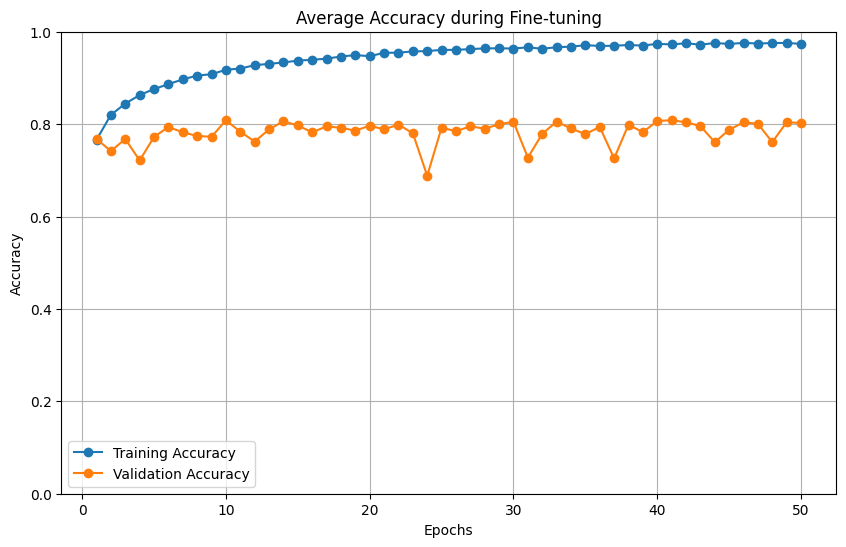

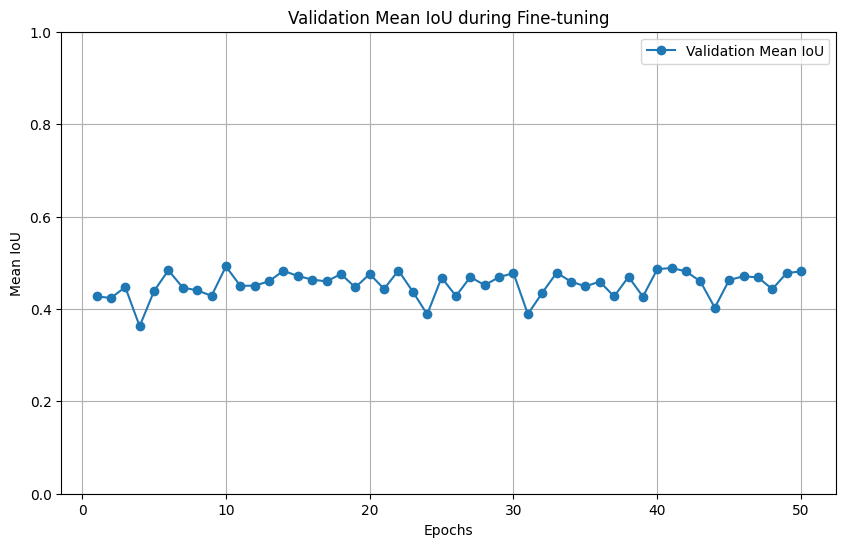


✅ Best fine-tuned model saved at 'seg_finetuned_best.weights.h5' (best epoch = 10).


In [ ]:
# ===============================================
# Cell 3 : Step 3 – Translate ➔ Crop ➔ Fine-tune (save best fine-tuned model)
# ===============================================

import os, glob, cv2, shutil, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

# ---------- 3.1 Translate Potsdam trainA & testA using g_AB --------------
def translate_folder(cg, src, dst, res=512, overwrite=False):
    """Translate every PNG in *src* with g_AB and save to *dst* (resized to 512×512)."""
    os.makedirs(dst, exist_ok=True)
    for p in glob.glob(src + "/*.png"):
        out = os.path.join(dst, os.path.basename(p))
        if not overwrite and os.path.exists(out):
            continue
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (res, res))
        fake = cg.g_AB((img/127.5 - 1)[None], training=False)[0].numpy()
        fake = ((fake * 0.5 + 0.5) * 255).astype(np.uint8)
        fake = cv2.cvtColor(fake, cv2.COLOR_RGB2BGR)
        cv2.imwrite(out, fake, [cv2.IMWRITE_PNG_COMPRESSION, 0])

# ---------- 3.2 Crop translated 512×512 images into 256×256 patches ------
def crop_translated_tiles(src_dir, dst_dir, patch_size=256):
    os.makedirs(f"{dst_dir}/images", exist_ok=True)
    img_files = sorted(glob.glob(src_dir + "/*.png"))
    cnt = 0
    for img_path in img_files:
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        name = os.path.splitext(os.path.basename(img_path))[0]
        for dy in [0, 256]:
            for dx in [0, 256]:
                crop = img[dy:dy+patch_size, dx:dx+patch_size]
                out_name = f"{name}_{dy//patch_size}_{dx//patch_size}.png"
                cv2.imwrite(os.path.join(f"{dst_dir}/images", out_name),
                            cv2.cvtColor(crop, cv2.COLOR_RGB2BGR),
                            [cv2.IMWRITE_PNG_COMPRESSION, 0])
                cnt += 1
    print(f"✅ Cropped and saved {cnt} image patches into {dst_dir}/images.")

# ---------- 3.3 Crop original masks to match cropped images --------------
def crop_masks(src_mask_dir, dst_dir, patch_size=256):
    os.makedirs(f"{dst_dir}/masks", exist_ok=True)
    mask_files = sorted(glob.glob(src_mask_dir + "/*.png"))
    cnt = 0
    for mask_path in mask_files:
        msk = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        h, w = msk.shape[:2]
        name = os.path.splitext(os.path.basename(mask_path))[0]
        for dy in [0, 256]:
            for dx in [0, 256]:
                crop = msk[dy:dy+patch_size, dx:dx+patch_size]
                out_name = f"{name}_{dy//patch_size}_{dx//patch_size}.png"
                cv2.imwrite(os.path.join(f"{dst_dir}/masks", out_name),
                            crop,
                            [cv2.IMWRITE_PNG_COMPRESSION, 0])
                cnt += 1
    print(f"✅ Cropped and saved {cnt} mask patches into {dst_dir}/masks.")

# ---------- 3.4 FULL PROCESS: Translate + Crop + Build Segmentation Data ----
print("─ Translating Potsdam tiles …")
translate_folder(cyg, src="./datasets/potsdam2vaihingen/trainA", dst="./translated_trainA")
translate_folder(cyg, src="./datasets/potsdam2vaihingen/testA", dst="./translated_valA")

# Crop translated images into 256×256 patches
crop_translated_tiles("./translated_trainA", "./seg_datasets/translated_seg_data")
crop_translated_tiles("./translated_valA", "./seg_datasets/translated_val_seg_data")

# Crop original masks to match patches
crop_masks("./seg_datasets/potsdam_train_seg_data/masks", "./seg_datasets/translated_seg_data")
crop_masks("./seg_datasets/potsdam_val_seg_data/masks", "./seg_datasets/translated_val_seg_data")

# ---------- 3.5 Fine-tune segmentation model (save only best) --------------

train_loader = SegDataLoader("translated_seg_data")
val_loader   = SegDataLoader("translated_val_seg_data")

# Reload model and compile
model.load_weights("seg_potsdam_best.weights.h5")
model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", MeanIoU_Custom(6)]
)

# best model tracking
best_val_miou = -np.inf
best_epoch = -1

# manual history
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": [], "val_mean_iou": []}

# Fine-tune full 50 epochs
for epoch in range(50):
    print(f"\n--- Epoch {epoch+1}/50 ---")

    h = model.fit(
        train_loader.batch(4),
        steps_per_epoch=max(1, len(train_loader)//4),
        epochs=1,
        validation_data=val_loader.batch(4, shuffle=False),
        validation_steps=max(1, len(val_loader)//4),
        verbose=1
    )

    # update history
    for k in history.keys():
        if k in h.history:
            history[k].append(h.history[k][0])

    val_miou = h.history["val_mean_iou"][0]

    # save best model manually
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch + 1
        model.save_weights("seg_finetuned_best.weights.h5")
        print(f"⭐ Best fine-tuned model updated at epoch {best_epoch} (val_mean_iou={best_val_miou:.4f})")

print(f"\n✅ Fine-tuning complete! Best epoch = {best_epoch} (val_mean_iou={best_val_miou:.4f})")

# ---------- 3.6 Plot training and validation metrics ------------------------
epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs, history["accuracy"], marker='o', label='Training Accuracy')
plt.plot(epochs, history["val_accuracy"], marker='o', label='Validation Accuracy')
plt.title('Average Accuracy during Fine-tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(epochs, history["val_mean_iou"], marker='o', label='Validation Mean IoU')
plt.title('Validation Mean IoU during Fine-tuning')
plt.xlabel('Epochs')
plt.ylabel('Mean IoU')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print(f"\n✅ Best fine-tuned model saved at 'seg_finetuned_best.weights.h5' (best epoch = {best_epoch}).")


In [ ]:
# ===============================================
# ✅ UPLOAD BEST FINE-TUNED MODEL TO GOOGLE DRIVE
# ===============================================

from google.colab import drive
drive.mount('/content/drive')  # Only needed once

# create a folder in your Drive if needed
save_dir = '/content/drive/MyDrive/segmentation_models'
os.makedirs(save_dir, exist_ok=True)

# copy best fine-tuned weights to Drive
import shutil
shutil.copy("seg_finetuned_best.weights.h5", save_dir)

print(f"✅ Fine-tuned best model uploaded to Google Drive at {save_dir}/seg_finetuned_best.weights.h5")


✓ loader: 88 image–mask pairs ready.

──────── Fine-tuned model evaluation on Vaihingen test set ────────
test loss        : 3.4501
overall accuracy : 0.3882
overall mIoU     : 0.1151

per-class results
───────────────────────────────────────────────
impervious    acc = 0.1379   iou = 0.1333
building      acc = 0.9338   iou = 0.3779
low veg       acc = 0.0438   iou = 0.0374
trees         acc = 0.0992   iou = 0.0946
cars          acc = 0.0771   iou = 0.0477
clutter       acc = 0.0000   iou = 0.0000

📸 Showing top 3 best predictions (by per-sample IoU)...


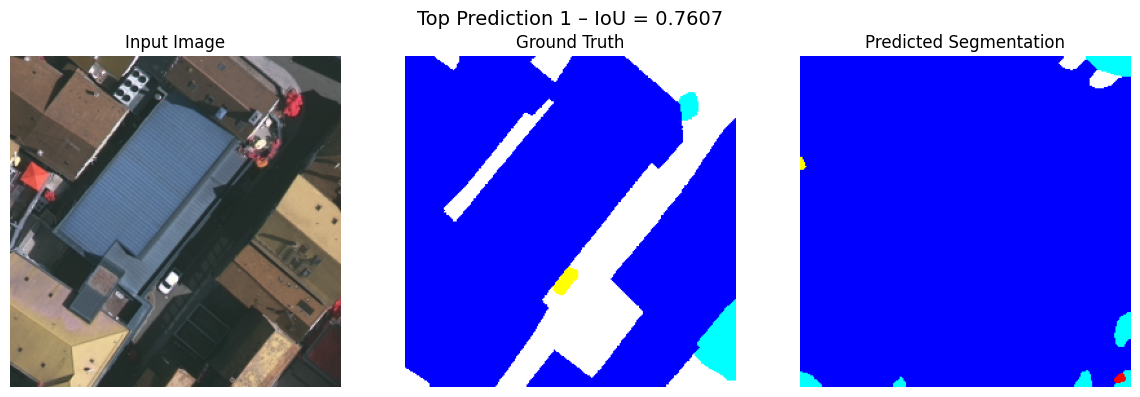

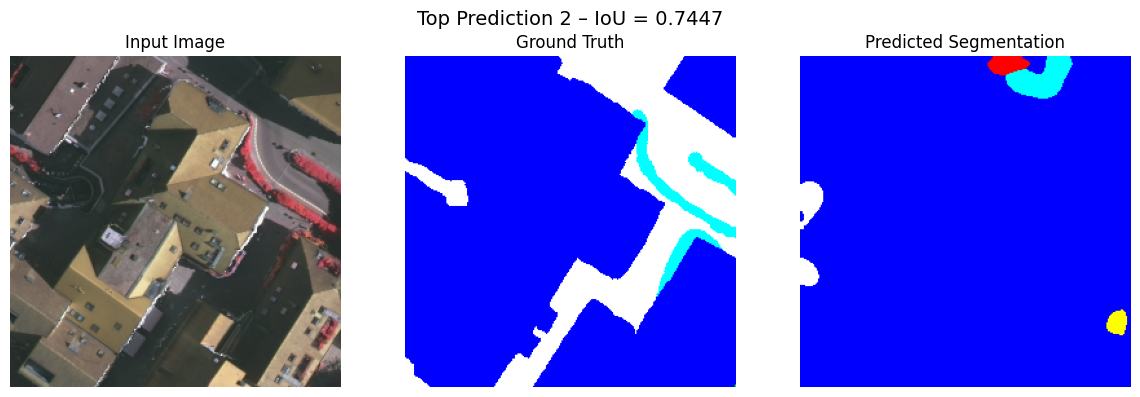

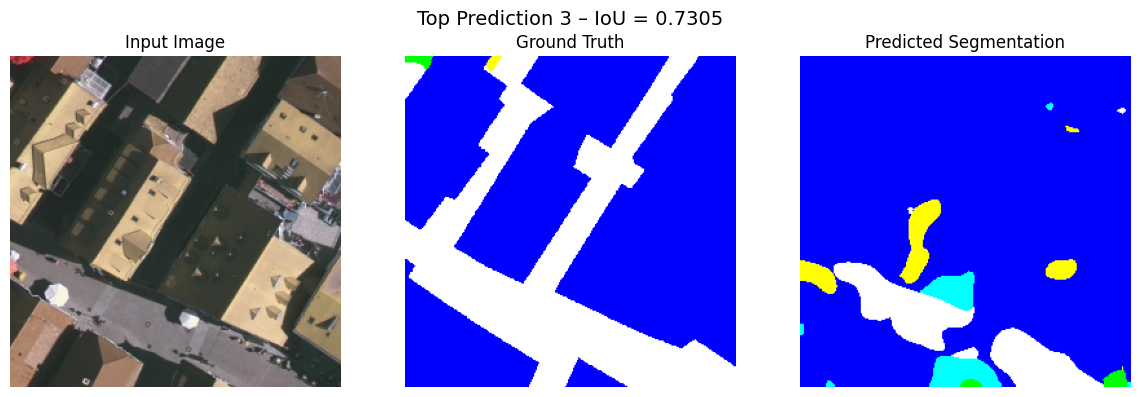

In [21]:
import numpy as np, tensorflow as tf, glob, cv2, os
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

# -------- 4.1 rebuild DeeplabV3 network ------------------
model = build_deeplabv3(num_classes=6, shape=(256,256,3))
model.load_weights("seg_finetuned_best.weights.h5")
model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", MeanIoU_Custom(6)]
)

# -------- 4.2 prepare Vaihingen test loader --------------
test_loader = SegDataLoader("vaihingen_test_seg_data", res=(256,256), ncls=6)

# -------- 4.3 quick Keras evaluate -----------------------
test_loss, test_acc, _ = model.evaluate(
    test_loader.batch(bs=4, shuffle=False),
    steps=max(1, test_loader.size // 4),
    verbose=0
)

# -------- 4.4 full confusion matrix ----------------------
yt, yp = [], []
for i in range(len(test_loader)):
    x, y_true = test_loader[i]
    y_pred    = model.predict(x[None], verbose=0)[0]
    yt.append(np.argmax(y_true, -1).flatten())
    yp.append(np.argmax(y_pred, -1).flatten())
yt = np.concatenate(yt)
yp = np.concatenate(yp)
cm = confusion_matrix(yt, yp, labels=range(6))

overall_acc = cm.diagonal().sum() / cm.sum()

# per-class acc & IoU
class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
ious = []
for c in range(6):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    denom = tp + fp + fn
    ious.append(tp / denom if denom > 0 else 0.0)
overall_miou = np.mean(ious)

# -------- 4.5 pretty print results ------------------------
cls_names = ["impervious", "building", "low veg", "trees", "cars", "clutter"]

print("\n──────── Fine-tuned model evaluation on Vaihingen test set ────────")
print(f"test loss        : {test_loss:.4f}")
print(f"overall accuracy : {overall_acc:.4f}")
print(f"overall mIoU     : {overall_miou:.4f}\n")
print("per-class results")
print("───────────────────────────────────────────────")
for name, acc, iou in zip(cls_names, class_acc, ious):
    print(f"{name:<12s}  acc = {acc:.4f}   iou = {iou:.4f}")




# -------- 4.6 visualize a few predictions ------------------------

def index2color(index_map):
    color_map = {
        0: (255, 255, 255),  # impervious
        1: (0, 0, 255),      # building
        2: (0, 255, 255),    # low vegetation
        3: (0, 255, 0),      # trees
        4: (255, 255, 0),    # cars
        5: (255, 0, 0)       # clutter
    }
    h, w = index_map.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in color_map.items():
        color_image[index_map == cls] = color
    return color_image


# -------- 4.6 visualize top 3 best predicted images ------------------------

def index2color(index_map):
    color_map = {
        0: (255, 255, 255),  # impervious
        1: (0, 0, 255),      # building
        2: (0, 255, 255),    # low vegetation
        3: (0, 255, 0),      # trees
        4: (255, 255, 0),    # cars
        5: (255, 0, 0)       # clutter
    }
    h, w = index_map.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in color_map.items():
        color_image[index_map == cls] = color
    return color_image

# collect IoU for each test sample
sample_results = []
for i in range(len(test_loader)):
    x, y_true = test_loader[i]
    y_pred = model.predict(x[None], verbose=0)[0]

    y_true_idx = np.argmax(y_true, axis=-1)
    y_pred_idx = np.argmax(y_pred, axis=-1)

    intersection = np.logical_and(y_true_idx == y_pred_idx, y_true_idx != 255).sum()
    union = np.logical_or(y_true_idx != 255, y_pred_idx != 255).sum()
    iou = intersection / union if union > 0 else 0.0

    sample_results.append((iou, x, y_true_idx, y_pred_idx))

# sort by IoU descending and pick top 3
top_samples = sorted(sample_results, key=lambda x: x[0], reverse=True)[:3]

print("\n📸 Showing top 3 best predictions (by per-sample IoU)...")
for i, (iou, x, y_true_idx, y_pred_idx) in enumerate(top_samples):
    img_disp  = (x * 255).astype(np.uint8)
    gt_disp   = index2color(y_true_idx)
    pred_disp = index2color(y_pred_idx)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Top Prediction {i+1} – IoU = {iou:.4f}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(img_disp)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_disp)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Segmentation")
    plt.imshow(pred_disp)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


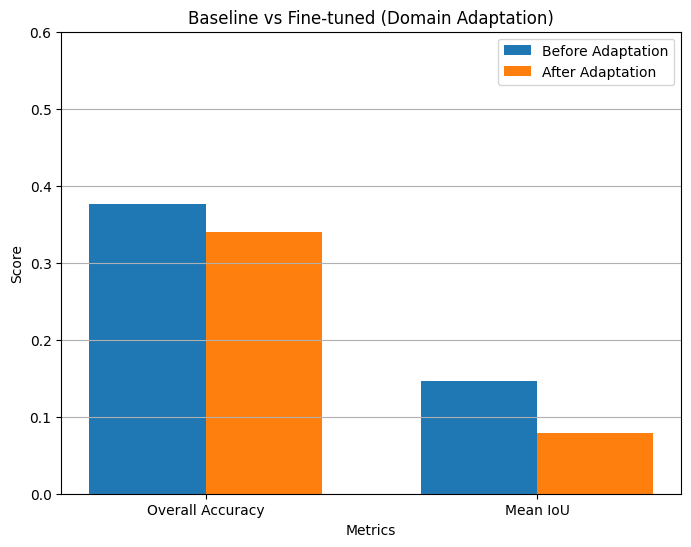

In [ ]:
import matplotlib.pyplot as plt

# metrics
labels = ["Overall Accuracy", "Mean IoU"]
baseline = [0.3762, 0.1462]   # before adaptation
finetuned = [0.3401, 0.0793]  # after adaptation

x = range(len(labels))
width = 0.35  # bar width

# plot
plt.figure(figsize=(8,6))
plt.bar(x, baseline, width=width, label="Before Adaptation", align="center")
plt.bar([i + width for i in x], finetuned, width=width, label="After Adaptation", align="center")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Baseline vs Fine-tuned (Domain Adaptation)")
plt.xticks([i + width/2 for i in x], labels)
plt.ylim(0, 0.6)
plt.grid(True, axis='y')
plt.legend()
plt.show()
